# S10 — Isolate and diagnose the points where tempering hurts (iterative LETKF, OSSE)

**Question.** The tempered (iterative) LETKF sometimes pushes the vertical-wind `w` analysis in a
non-physical direction: the prior has an updraft and the analysis produces a downdraft. `w` is
**not observed** (H uses only qr/qs/qg/T/P), so every change in `w` comes from the cross-covariance
`cov(w, dBZ)`. Hypothesis: at these points very few ensemble members carry an echo, the `w` ensemble
is highly skewed, the mean is small, and the update is dominated by a few high-value members —
producing a large, wrongly-directed increment for a given departure.

**Goal.** (1) Isolate the points where tempering degrades skill and where it helps; (2) confirm or
refute the "few echo members / skewed ensemble" mechanism by quantifying per-point drivers;
(3) explain, for the same departure, what sends the update to the right vs the wrong side;
(4) contrast single-obs vs multi-obs (loc=0.1 and loc=2.0).

**Purely diagnostic on existing outputs — no DA re-runs.** Reuses the validated H operator and the
single-point machinery from S9, the closed-form `cov(w,dBZ)` inversion and the single/multi
cross-load from S7.

**Primary skill classifier:** reflectivity residual in dBZ (the `w`-based version is reported
alongside). Standard = `TEnKF Nt=1`; tempered = `Nt>=2`.

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

REPO = '/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation'
D    = f'{REPO}/data'
sys.path.insert(0, f'{REPO}/src/fortran')     # only to validate the H operator (calc_ref)

VI   = {'qg':0,'qr':1,'qs':2,'T':3,'P':4,'u':5,'v':6,'w':7}
VARS = ['qg','qr','qs','T','P','u','v','w']
IW   = VI['w']
R0      = 5.0        # obs.obs_error_var  (dBZ^2)
DBZ_MIN = 0.0
TM      = 0          # truth member; prior = members 1..59
NX, NY, NZ = 558, 898, 11
PI, RD  = 3.14159265358979, 287.0

SUBSET = f'{D}/3D_subsets_20240319_GUES_20240319180000/subset_20240319180000.npz'
SWEEP  = f'{D}/WS_singleobs_xsec_1800_GUES/WS_singleobs_xsec_1800_GUES_sweep_Ne059_tm00.npz'
MO = {   # multi-obs experiments at Ne=59 (single vs multi contrast)
    'loc0.1': (f'{D}/WS_diag1800_MO_L0.1_Ne59', 'WS_diag1800_MO_L0.1_Ne59', 'Lx0.1Ly0.1Lz0.1', 'Ne059'),
    'loc2.0': (f'{D}/WS_diag1800_MO_L2.0_Ne59', 'WS_diag1800_MO_L2.0_Ne59', 'Lx2.0Ly2.0Lz2.0', 'Ne059'),
}
OUT = f'{D}/derived_S10_flagged_points.npz'

W_MIN       = 0.05    # |w| below this = noise (does not count as a physical change)
TARGET_STEP = 'Nt2'   # tempering target for the primary classification
plt.rcParams['figure.dpi'] = 110
print('config ready')

config ready


## 1. Load the sweep (single-obs) and align the combos point by point

In [2]:
d = np.load(SWEEP, allow_pickle=True)
method, ntemp = d['method'].astype(str), d['ntemp']

def rows(meth, nt):
    '''Rows of one combo, sorted by (i,j,k) so all combos align point for point.'''
    m = (method == meth) & (ntemp == nt)
    key = (d['i'][m].astype(np.int64) * 1000 + d['j'][m]) * 100 + d['k'][m]
    return m, np.argsort(key)

def col(name, m, o):
    return d[name][m][o].astype(np.float64)

COMBOS = {'AOEI': ('AOEI', 1), 'Nt1': ('TEnKF', 1), 'Nt2': ('TEnKF', 2), 'Nt3': ('TEnKF', 3)}
print('available combos:',
      {k: int(((method == v[0]) & (ntemp == v[1])).sum()) for k, v in COMBOS.items()})

# reference ordering = standard LETKF (TEnKF Nt=1)
m_l, o_l = rows('TEnKF', 1)
I, J, K = d['i'][m_l][o_l], d['j'][m_l][o_l], d['k'][m_l][o_l]
npts = I.size

# prior quantities (combo-invariant: same prior, same observation)
wf     = col('mean_f_point_w',  m_l, o_l)     # prior w at the point
wt     = col('truth_point_w',   m_l, o_l)     # truth w
dep_b  = col('dep_b',           m_l, o_l)     # yo - H(prior)  (noisy)
hxf    = col('hxf_mean_obs',    m_l, o_l)     # prior mean H(x) [dBZ]
yo_cln = col('yo_clean',        m_l, o_l)     # noise-free truth reflectivity
var_h  = col('spread_f_obs',    m_l, o_l) ** 2
skew_w = col('skew_f_point_w',  m_l, o_l)     # skewness of the prior w ensemble
sprd_w = col('spread_f_point_w', m_l, o_l)    # prior w spread

# analysis w and analysis reflectivity per combo, aligned to (I,J,K)
wa, hxa = {}, {}
for name, (mm, nt) in COMBOS.items():
    m, o = rows(mm, nt)
    assert np.array_equal(d['i'][m][o], I) and np.array_equal(d['j'][m][o], J) \
        and np.array_equal(d['k'][m][o], K), f'{name}: point ordering mismatch'
    wa[name]  = col('mean_a_point_w', m, o)
    hxa[name] = col('hxa_mean_obs',   m, o)

print(f'{npts:,} single-obs points (Ne=59, loc=0.1); per-combo arrays aligned')

available combos: {'AOEI': 750931, 'Nt1': 750931, 'Nt2': 750931, 'Nt3': 750931}
750,931 single-obs points (Ne=59, loc=0.1); per-combo arrays aligned


## 2. dBZ skill (primary classifier) and the `w` pathology

Everything is measured against the **noise-free** truth (`yo_clean`) so that the sweep and the
multi-obs fields are on equal footing. Two axes: observation-space skill (dBZ, the chosen primary
classifier) and `w` error (the physical variable of interest).

In [3]:
# --- observation-space skill (dBZ), against the NOISE-FREE truth ---
Ef = np.abs(hxf - yo_cln)                            # prior error in dBZ
Ea = {n: np.abs(hxa[n] - yo_cln) for n in COMBOS}    # analysis error in dBZ per combo

# --- w (vertical wind) error at the point ---
ef = np.abs(wf - wt)
ea = {n: np.abs(wa[n] - wt) for n in COMBOS}
dw = {n: wa[n] - wf for n in COMBOS}                 # w increment

valid = np.isfinite(dep_b) & np.isfinite(wt) & np.isfinite(wf) & np.isfinite(Ef)
hi    = valid & (K >= 2)                             # k>=2 avoids the surface vertical coupling at loc=0.1
T, S  = TARGET_STEP, 'Nt1'                            # tempered vs standard

# axis 1 (PRIMARY): dBZ skill of tempered vs standard and prior
temper_worse_std   = valid & (Ea[T] > Ea[S] + 1e-6)
temper_worse_prior = valid & (Ea[T] > Ef    + 1e-6)
pathological       = temper_worse_std & temper_worse_prior            # worse than standard AND prior (dBZ)
temper_better_std  = valid & (Ea[T] < Ea[S] - 1e-6)
temper_helpful     = temper_better_std & (Ea[T] < Ef - 1e-6)          # better than standard AND prior (dBZ)

# axis 2 (physical): the same but measured on the w error
w_patho   = valid & (ea[T] > ea[S] + 1e-6) & (ea[T] > ef + 1e-6)
w_helpful = valid & (ea[T] < ea[S] - 1e-6) & (ea[T] < ef - 1e-6)

# any update that INCREASES the w error (with or without a sign change)
w_worse = {n: valid & (ea[n] > ef + 1e-6) for n in COMBOS}
sflip   = {n: valid & (np.sign(wa[n]) != np.sign(wf)) & (np.abs(wf) > W_MIN) & (np.abs(wa[n]) > W_MIN)
           for n in COMBOS}

def pct(m):
    return f'{int(m.sum()):>8d}  ({m.sum()/valid.sum():6.2%})'

print(f'valid points: {int(valid.sum()):,}   (k>=2: {int(hi.sum()):,})\n')
print('== PRIMARY AXIS: dBZ skill (Nt2 vs Nt1 vs prior) ==')
print(f'  tempering WORSE than standard    : {pct(temper_worse_std)}')
print(f'  tempering WORSE than prior        : {pct(temper_worse_prior)}')
print(f'  PATHOLOGICAL dBZ (worse than both): {pct(pathological)}')
print(f'  tempering HELPFUL dBZ (better both): {pct(temper_helpful)}\n')
print('== PHYSICAL AXIS: w error (Nt2 vs Nt1 vs prior) ==')
print(f'  PATHOLOGICAL w (worse than both)  : {pct(w_patho)}')
print(f'  HELPFUL w (better than both)      : {pct(w_helpful)}\n')
print('== w error INCREASES / sign change (per combo) ==')
for n in COMBOS:
    print(f'  {n:4s}: w worsens {pct(w_worse[n])}   | sign change {pct(sflip[n])}')

# contingency table: dBZ degradation  x  w error increase (Nt2)
obs_bad = valid & (Ea[T] > Ea[S]); wv_bad = valid & (ea[T] > ef)
print('\n== contingency Nt2:  rows=dBZ skill, cols=w error ==')
print(f'{"":16s}{"w better":>12s}{"w worse":>12s}')
for lbl, om in (('dBZ better', valid & ~obs_bad), ('dBZ worse', obs_bad)):
    print(f'{lbl:16s}{int((om & ~wv_bad).sum()):>12d}{int((om & wv_bad).sum()):>12d}')

valid points: 750,908   (k>=2: 600,876)

== PRIMARY AXIS: dBZ skill (Nt2 vs Nt1 vs prior) ==
  tempering WORSE than standard    :   209874  (27.95%)
  tempering WORSE than prior        :   125825  (16.76%)
  PATHOLOGICAL dBZ (worse than both):    98055  (13.06%)
  tempering HELPFUL dBZ (better both):   507192  (67.54%)

== PHYSICAL AXIS: w error (Nt2 vs Nt1 vs prior) ==
  PATHOLOGICAL w (worse than both)  :   301453  (40.15%)
  HELPFUL w (better than both)      :   263589  (35.10%)

== w error INCREASES / sign change (per combo) ==
  AOEI: w worsens   365749  (48.71%)   | sign change    25626  ( 3.41%)
  Nt1 : w worsens   368514  (49.08%)   | sign change    27549  ( 3.67%)
  Nt2 : w worsens   383142  (51.02%)   | sign change    65078  ( 8.67%)
  Nt3 : w worsens   385126  (51.29%)   | sign change    64558  ( 8.60%)

== contingency Nt2:  rows=dBZ skill, cols=w error ==
                    w better     w worse
dBZ better            259055      274371
dBZ worse             107807      1096

## 3. Closed-form drivers: `cov(w,dBZ)` and gain (no ensemble read)

For a scalar observation at its own cell the LETKF collapses exactly to the scalar Kalman update
`dw = dep * cov(w,h)/(var(h)+R)`, so `cov(w,h)` is recoverable from data already on disk. Exact for
`Nt=1` (w is never clamped).

In [4]:
ok = np.abs(dep_b) > 1e-3
cov_wh = np.full(npts, np.nan)
cov_wh[ok] = dw['Nt1'][ok] * (var_h[ok] + R0) / dep_b[ok]    # inversion
gain = cov_wh / (var_h + R0)

chk = np.nanmedian(np.abs(gain * dep_b - dw['Nt1']))
print(f'check  gain*dep_b vs stored LETKF increment: median|diff| = {chk:.2e} m/s')
print(f'cov(w,dBZ) < 0 at {np.nanmean(cov_wh[ok] < 0):.1%} of points')
print(f'  at pathological-w points: cov<0 at {np.nanmean(cov_wh[w_patho] < 0):.1%}')

check  gain*dep_b vs stored LETKF increment: median|diff| = 0.00e+00 m/s
cov(w,dBZ) < 0 at 47.6% of points
  at pathological-w points: cov<0 at 47.8%


## 4. The "few echo members" test: go to the ensemble

A negative `cov(w,dBZ)` only matters if the ensemble carries information. Reflectivity is floored at
`dbz_min=0`, so in a clear-air column almost all members sit at 0 dBZ. We read the prior ensemble
(once, ~10.6 GB) at the flagged subset + a control.

In [5]:
# H (reflectivity) ported from calc_ref (Tong & Xue 2006), vectorized; validated vs Fortran.
def calc_ref_np(qr, qs, qg, T, P, min_dbz=DBZ_MIN):
    qr, qs, qg, T, P = (np.asarray(a, np.float64) for a in (qr, qs, qg, T, P))
    nor, nos, nog = 8.0e6, 2.0e6, 4.0e6
    ror, ros, rog, roi = 1000.0, 100.0, 913.0, 917.0
    ki2, kr2 = 0.176, 0.930
    pip = PI ** 1.75
    cf  = 1e18 * 720.0 / (pip * nor**0.75 * ror**1.75)
    cf2 = 1e18 * 720.0 * ki2 * ros**0.25 / (pip * kr2 * nos**0.75 * roi**2.0)
    cf3 = 1e18 * 720.0 / (pip * nos**0.75 * ros**1.75)
    cf4 = (1e18 * 720.0 / (pip * nog**0.75 * rog**1.75)) ** 0.95
    ro = P / (RD * T)
    with np.errstate(invalid='ignore'):    # base<0 in the branches where q<=0 (discarded by where)
        zr = np.where(qr > 0.0, cf * np.maximum(ro * qr, 0.0) ** 1.75, 0.0)
        qs_ = np.maximum(qs, 0.0)
        zs = np.where(qs > 0.0, np.where(T <= 273.16, cf2, cf3) * np.maximum(ro * qs_, 0.0) ** 1.75, 0.0)
        zg = np.where(qg > 0.0, cf4 * np.maximum(ro * qg, 0.0) ** 1.6625, 0.0)
    z  = zr + zs + zg
    ref = np.where(z > 0.0, 10.0 * np.log10(np.where(z > 0.0, z, 1.0)), min_dbz)
    return np.maximum(ref, min_dbz)

def Hmembers(state):
    '''state (..., nvar) -> reflectivity (...,) per member.'''
    return calc_ref_np(state[..., VI['qr']], state[..., VI['qs']], state[..., VI['qg']],
                       state[..., VI['T']],  state[..., VI['P']])

from cletkf_wloc import common_da as cda
_r = np.random.default_rng(0); _n = 3000
_a = [_r.uniform(0, 3e-3, _n), _r.uniform(0, 3e-3, _n), _r.uniform(0, 3e-3, _n),
      _r.uniform(220, 300, _n), _r.uniform(2e4, 1e5, _n)]
_ftn = np.maximum(np.array([cda.calc_ref(_a[0][i], _a[1][i], _a[2][i], _a[3][i], _a[4][i], min_dbz=DBZ_MIN)
                            for i in range(_n)]), DBZ_MIN)
assert np.abs(calc_ref_np(*_a) - _ftn).max() < 1e-4, 'H port disagrees with Fortran'
print(f'H port vs Fortran: max|diff| = {np.abs(calc_ref_np(*_a) - _ftn).max():.2e} dBZ  (OK)')

H port vs Fortran: max|diff| = 0.00e+00 dBZ  (OK)


In [6]:
# select the flagged subset + representatives for figures, and read the ensemble ONCE.
flag = (pathological | w_patho | temper_helpful | w_helpful | w_worse['Nt2'] | sflip['Nt2']) & valid
rng  = np.random.default_rng(7)
ctrl_pool = np.flatnonzero(valid & ~flag)
n_ctrl = min(30000, ctrl_pool.size)
ctrl = rng.choice(ctrl_pool, n_ctrl, replace=False)
sel  = np.concatenate([np.flatnonzero(flag), ctrl])
print(f'flagged points: {int(flag.sum()):,}  + control {n_ctrl:,}  = {sel.size:,} to read')

REP, _used = {}, set()
for lbl, mk in (('pathological', w_patho), ('helpful', w_helpful), ('sign-flip', sflip['Nt2'])):
    idx = np.flatnonzero(mk & (K >= 2))
    if idx.size == 0: continue
    for p in idx[np.argsort(-np.abs(dw['Nt2'][idx]))]:   # largest to smallest |w increment|
        cell = (int(I[p]), int(J[p]), int(K[p]))
        if cell not in _used:
            REP[lbl] = cell; _used.add(cell); break
print('representatives:', REP)

HW = 12   # cross-section half-width (i cells)
t0 = time.time()
with np.load(SUBSET) as z:
    se  = z['state_ensemble']                         # (nx,ny,nz,60,8), ~10.6 GB in RAM
    POS = z['pos_km'].astype(np.float64)
    ii, jj, kk = I[sel], J[sel], K[sel]
    sub = se[ii, jj, kk, :, :].astype(np.float64)     # (nsel, 60, 8)
    XS = {}
    for lbl, (ci, cj, ck) in REP.items():
        i0, i1 = max(0, ci - HW), min(NX, ci + HW + 1)
        XS[lbl] = dict(cube=se[i0:i1, cj, :, :, :].astype(np.float64).copy(),   # (ni,nz,60,8)
                       i0=i0, ci=ci, cj=cj, ck=ck,
                       x=POS[i0:i1, cj, :, 0].copy(), zk=POS[ci, cj, :, 2].copy())
    del se
print(f'read in {time.time()-t0:.0f} s   sub={sub.shape}')

members = [x for x in range(sub.shape[1]) if x != TM]
NE = len(members)
xf_e  = sub[:, members, :]            # (nsel, NE, 8)
tru_e = sub[:, TM, :]                 # (nsel, 8)
h_e   = Hmembers(xf_e)               # (nsel, NE)  reflectivity per member
w_e   = xf_e[:, :, IW]               # (nsel, NE)  w per member

flagged points: 720,403  + control 30,000  = 750,403 to read
representatives: {'pathological': (272, 460, 10), 'helpful': (254, 726, 10), 'sign-flip': (58, 254, 8)}
read in 55 s   sub=(750403, 60, 8)


In [7]:
# per-point diagnostics from the ensemble
hm = h_e.mean(1, keepdims=True); wm = w_e.mean(1, keepdims=True)
cov_dir = ((w_e - wm) * (h_e - hm)).sum(1) / (NE - 1)
var_dir = ((h_e - hm) ** 2).sum(1) / (NE - 1)
n_active = (h_e > DBZ_MIN).sum(1)
wmin, wmax = w_e.min(1), w_e.max(1)

contrib = (w_e - wm) * (h_e - hm) / (NE - 1)          # (nsel, NE)
den = contrib.sum(1)
frac_echo = np.where(np.abs(den) > 0,
                     np.where(h_e > DBZ_MIN, contrib, 0.0).sum(1) / den, np.nan)

def to_full(vals):
    out = np.full(npts, np.nan); out[sel] = vals; return out
NACT = to_full(n_active.astype(float))
FRAC = to_full(frac_echo)
COVD = to_full(cov_dir)
WOUT = to_full(((wa['Nt1'][sel] < wmin - 1e-6) | (wa['Nt1'][sel] > wmax + 1e-6)).astype(float))
TOUT = to_full(((wt[sel] < wmin) | (wt[sel] > wmax)).astype(float))

sp_err = np.nanmax(np.abs(np.sqrt(var_dir) - col('spread_f_obs', m_l, o_l)[sel]))
gd = np.isfinite(cov_dir) & np.isfinite(cov_wh[sel])
cc = np.corrcoef(cov_dir[gd], cov_wh[sel][gd])[0, 1]
print(f'spread_f_obs reconstruction: max|diff| = {sp_err:.2e} dBZ')
print(f'direct cov vs closed form: corr = {cc:.6f}, '
      f'median|diff| = {np.nanmedian(np.abs(cov_dir - cov_wh[sel])[gd]):.2e}')
assert cc > 0.999, 'direct cov disagrees with the closed form'

spread_f_obs reconstruction: max|diff| = 3.36e-06 dBZ
direct cov vs closed form: corr = 1.000000, median|diff| = 3.87e-07


driver             patho-w      help-w     w worse     control
n_active             5.000       4.000       5.000       2.000
|skew w|             0.942       0.874       0.882       0.496
|cov(w,dBZ)|         0.363       0.307       0.348       0.021
|gain|               0.010       0.009       0.009       0.003
spread w             0.326       0.308       0.318       0.237
frac_echo            0.961       0.962       0.956       0.983


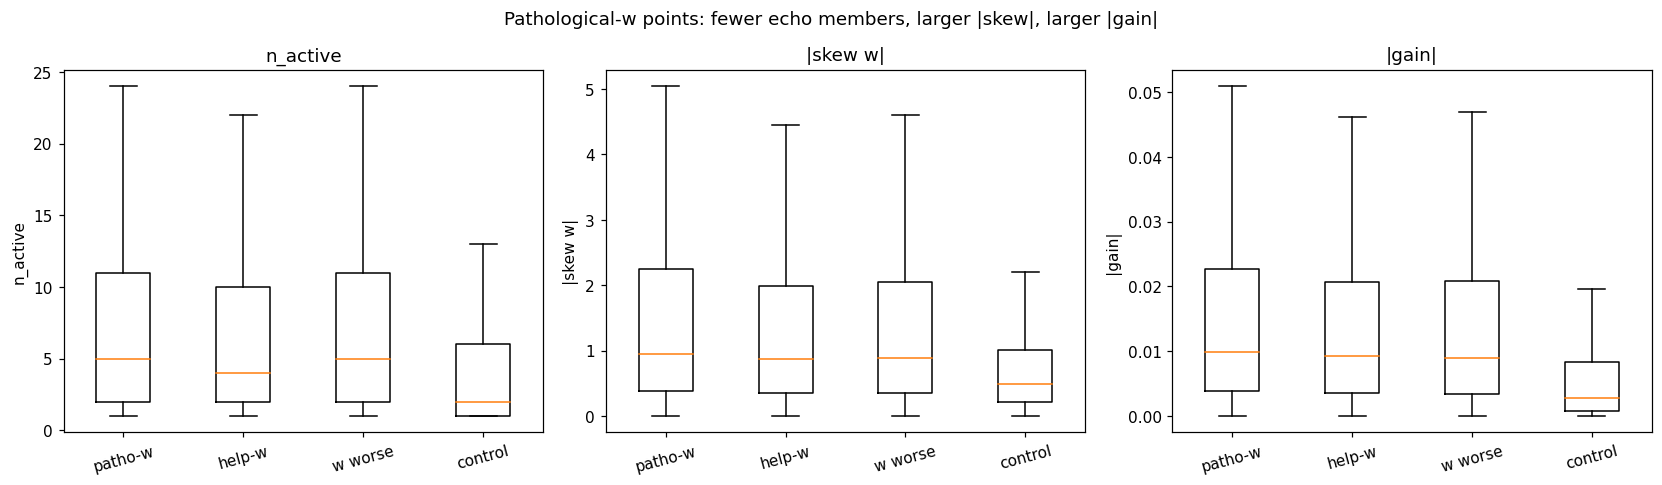

In [8]:
# driver comparison by category (hypothesis test)
cats = {
    'patho-w':  w_patho[sel],
    'help-w':   w_helpful[sel],
    'w worse':  w_worse['Nt2'][sel],
    'control':  (~flag)[sel],
}
drivers = {
    'n_active':     NACT[sel],
    '|skew w|':     np.abs(skew_w[sel]),
    '|cov(w,dBZ)|': np.abs(cov_dir),
    '|gain|':       np.abs(gain[sel]),
    'spread w':     sprd_w[sel],
    'frac_echo':    FRAC[sel],
}
print(f'{"driver":14s} ' + ' '.join(f'{c:>11s}' for c in cats))
for dn, dv in drivers.items():
    meds = []
    for cm in cats.values():
        v = dv[cm & np.isfinite(dv)]
        meds.append(f'{np.median(v):>11.3f}' if v.size else f'{"--":>11s}')
    print(f'{dn:14s} ' + ' '.join(meds))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)
for a, dn in zip(ax, ('n_active', '|skew w|', '|gain|')):
    data = [drivers[dn][cm & np.isfinite(drivers[dn])] for cm in cats.values()]
    a.boxplot(data, labels=list(cats.keys()), showfliers=False)
    a.set_title(dn); a.set_ylabel(dn); a.tick_params(axis='x', rotation=15)
fig.suptitle('Pathological-w points: fewer echo members, larger |skew|, larger |gain|')
plt.show()

## 5. Same departure: what sends the update to the right vs the wrong side

Conditioning on `|dep_b|`, split the update that moves `w` **toward** the truth from the one that
moves it **away**, and compare drivers. The sign of `cov(w,dBZ)` (via the gain) decides the side;
low `n_active` and high `|skew|` mark the misdirected cases.

     |dep_b|        n  % wrong  nact good  nact bad  |skew|good  |skew|bad
   0-5          50785    44.7%        4.0       3.0        0.90       0.73
   5-10         11399    31.7%       17.0      16.0        2.37       1.26
  10-20          8442    39.1%       24.0      20.0        1.90       1.56
  20-40          9058    45.7%       13.0      13.0        1.22       1.70
  40-80          1551    46.7%        9.0       8.0        1.62       1.66


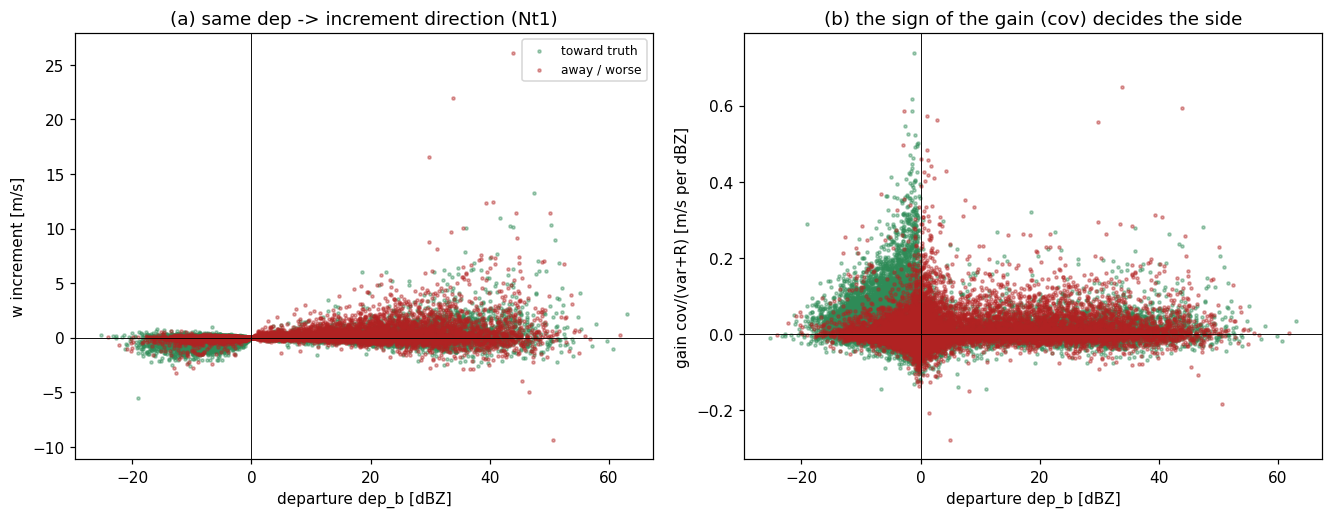

In [9]:
STEP = 'Nt1'   # LETKF: exact closed-form gain (change to 'Nt2' for the tempered case)
toward = np.sign(dw[STEP]) == np.sign(wt - wf)
good = valid & toward & (ea[STEP] < ef - 1e-6)
bad  = valid & (ea[STEP] > ef + 1e-6)
sig  = valid & (np.abs(wt - wf) > 0.5)            # only where there is an appreciable w correction

def med(arr, mk):
    v = arr[mk & np.isfinite(arr)]; return np.median(v) if v.size else np.nan

print(f'{"|dep_b|":>12s} {"n":>8s} {"% wrong":>8s} {"nact good":>10s} {"nact bad":>9s} '
      f'{"|skew|good":>11s} {"|skew|bad":>10s}')
for lo, up in zip([0,5,10,20,40,80], [5,10,20,40,80,300]):
    b = sig & (np.abs(dep_b) >= lo) & (np.abs(dep_b) < up)
    if b.sum() == 0: continue
    gb, bb = b & good, b & bad
    print(f'{lo:>4d}-{up:<7d} {int(b.sum()):>8d} {bb.sum()/b.sum():>8.1%} '
          f'{med(NACT, gb):>10.1f} {med(NACT, bb):>9.1f} '
          f'{med(np.abs(skew_w), gb):>11.2f} {med(np.abs(skew_w), bb):>10.2f}')

sm = sig & np.isfinite(dep_b) & np.isfinite(dw[STEP])
sm &= rng.random(npts) < (40000.0 / max(int(sm.sum()), 1))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
ax[0].scatter(dep_b[sm & good], dw[STEP][sm & good], s=4, c='seagreen', alpha=.4, label='toward truth')
ax[0].scatter(dep_b[sm & bad],  dw[STEP][sm & bad],  s=4, c='firebrick', alpha=.4, label='away / worse')
ax[0].axhline(0, c='k', lw=.6); ax[0].axvline(0, c='k', lw=.6)
ax[0].set_xlabel('departure dep_b [dBZ]'); ax[0].set_ylabel('w increment [m/s]')
ax[0].set_title(f'(a) same dep -> increment direction ({STEP})'); ax[0].legend(fontsize=8)
ax[1].scatter(dep_b[sm & good], gain[sm & good], s=4, c='seagreen', alpha=.4)
ax[1].scatter(dep_b[sm & bad],  gain[sm & bad],  s=4, c='firebrick', alpha=.4)
ax[1].axhline(0, c='k', lw=.6); ax[1].axvline(0, c='k', lw=.6)
ax[1].set_xlabel('departure dep_b [dBZ]'); ax[1].set_ylabel('gain cov/(var+R) [m/s per dBZ]')
ax[1].set_title('(b) the sign of the gain (cov) decides the side')
plt.show()

## 6. Single-obs vs multi-obs contrast (loc=0.1 and loc=2.0, Ne=59)

The multi-obs increment is exactly `bias_a_field - bias_f_field` (the truth cancels). Each run uses
its own prior (read from its `ref`). loc=0.1 should match the sweep for k>=2; loc=2.0 shows the
interference from neighbouring observations.

In [10]:
FN = {'Nt1':'TEnKF_Nt01', 'Nt2':'TEnKF_Nt02', 'Nt3':'TEnKF_Nt03', 'AOEI':'AOEI_Nt01'}
def load_mo(lockey, step):
    dirp, tag, lstr, nestr = MO[lockey]
    rp = f'{dirp}/{tag}_multi_obs_ref_{nestr}_tm00.npz'
    cp = f'{dirp}/{tag}_multi_obs_{FN[step]}_as1.0_{lstr}_{nestr}_tm00.npz'
    with np.load(rp) as r:
        wf_mo = r['xf_mean'][..., IW].astype(np.float64)
        ix, iy, iz = r['ix'], r['iy'], r['iz']
        thx = r['truth_hx'].astype(np.float64)
    with np.load(cp) as f:
        dw_mo  = (f['bias_a_field'][..., IW] - f['bias_f_field'][..., IW]).astype(np.float64)
        hxa_mo = f['hxa_mean_field'].astype(np.float64)
        hxf_mo = f['hxf_mean_field'].astype(np.float64)
    obs = np.zeros((NX, NY, NZ), bool); obs[ix, iy, iz] = True
    return dict(wf=wf_mo, dw=dw_mo, hxa=hxa_mo, hxf=hxf_mo, thx=thx, obs=obs)

for lockey in ('loc0.1', 'loc2.0'):
    mo1, mo2 = load_mo(lockey, 'Nt1'), load_mo(lockey, 'Nt2')
    inmask = mo1['obs'][I, J, K] & valid
    wf_m  = mo1['wf'][I, J, K]
    wa1_m = wf_m + mo1['dw'][I, J, K]
    wa2_m = mo2['wf'][I, J, K] + mo2['dw'][I, J, K]
    Ea1_m = np.abs(mo1['hxa'][I, J, K] - mo1['thx'][I, J, K])
    Ea2_m = np.abs(mo2['hxa'][I, J, K] - mo2['thx'][I, J, K])
    Ef_m  = np.abs(mo1['hxf'][I, J, K] - mo1['thx'][I, J, K])
    ef_m  = np.abs(wf_m - wt); ea2_m = np.abs(wa2_m - wt)
    patho_m = inmask & (Ea2_m > Ea1_m) & (Ea2_m > Ef_m)         # pathological dBZ in multi
    wpatho_m = inmask & (ea2_m > np.abs(wa1_m - wt)) & (ea2_m > ef_m)
    both = w_patho & inmask
    print(f'\n=== multi-obs {lockey} (Ne=59): {int(inmask.sum()):,} shared observed points ===')
    print(f'  pathological-w:  single={int((w_patho & inmask).sum()):,}   multi={int(wpatho_m.sum()):,}')
    print(f'  pathological-dBZ: single={int((pathological & inmask).sum()):,}   multi={int(patho_m.sum()):,}')
    if both.sum():
        print(f'  of {int(both.sum()):,} pathological-w in single-obs: still pathological-w in multi '
              f'{int((both & wpatho_m).sum()):,}  ({(both & wpatho_m).sum()/both.sum():.1%})')
    dws = dw['Nt2'][inmask]; dwm = (wa2_m - wf_m)[inmask]
    g = np.isfinite(dws) & np.isfinite(dwm)
    if g.sum():
        print(f'  corr w increment (Nt2) single vs multi: {np.corrcoef(dws[g], dwm[g])[0,1]:.3f}')


=== multi-obs loc0.1 (Ne=59): 693,762 shared observed points ===
  pathological-w:  single=278,379   multi=281,113
  pathological-dBZ: single=90,542   multi=91,165
  of 278,379 pathological-w in single-obs: still pathological-w in multi 275,977  (99.1%)
  corr w increment (Nt2) single vs multi: 1.000

=== multi-obs loc2.0 (Ne=59): 693,762 shared observed points ===
  pathological-w:  single=278,379   multi=300,404
  pathological-dBZ: single=90,542   multi=66,497
  of 278,379 pathological-w in single-obs: still pathological-w in multi 164,851  (59.2%)
  corr w increment (Nt2) single vs multi: 0.679


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


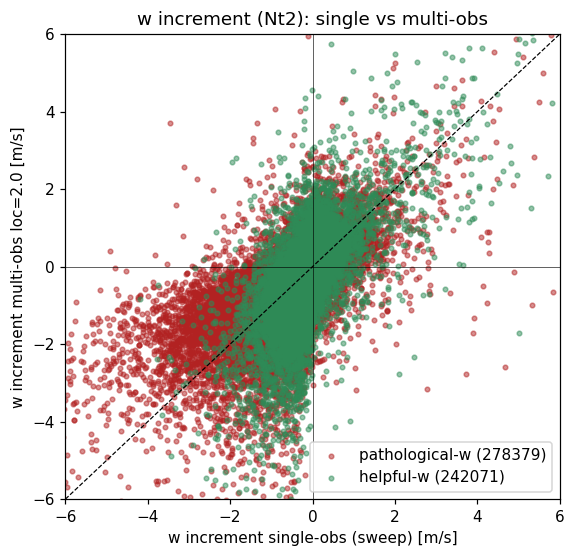

In [11]:
# w increment scatter: single-obs vs multi-obs loc=2.0 (where neighbouring obs interfere)
mo1, mo2 = load_mo('loc2.0', 'Nt1'), load_mo('loc2.0', 'Nt2')
inmask = mo1['obs'][I, J, K] & valid
wf_m = mo1['wf'][I, J, K]; dwm = mo2['wf'][I, J, K] + mo2['dw'][I, J, K] - wf_m
fig, ax = plt.subplots(figsize=(5.8, 5.6))
for lbl, cm, c in (('pathological-w', w_patho, 'firebrick'), ('helpful-w', w_helpful, 'seagreen')):
    mk = inmask & cm
    ax.scatter(dw['Nt2'][mk], dwm[mk], s=9, c=c, alpha=.5, label=f'{lbl} ({int(mk.sum())})')
lim = 6
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=.8); ax.axhline(0, c='k', lw=.4); ax.axvline(0, c='k', lw=.4)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('w increment single-obs (sweep) [m/s]')
ax.set_ylabel('w increment multi-obs loc=2.0 [m/s]')
ax.set_title('w increment (Nt2): single vs multi-obs'); ax.legend()
plt.show()

## 7. Per-point detail: why `w` flips

For each representative: the (dBZ, w) regression that sets the gain, the per-member contribution to
`cov(w,dBZ)` (how few members carry it), and the prior hull vs analysis vs truth.

--- pathological: (272, 460, 10) ---


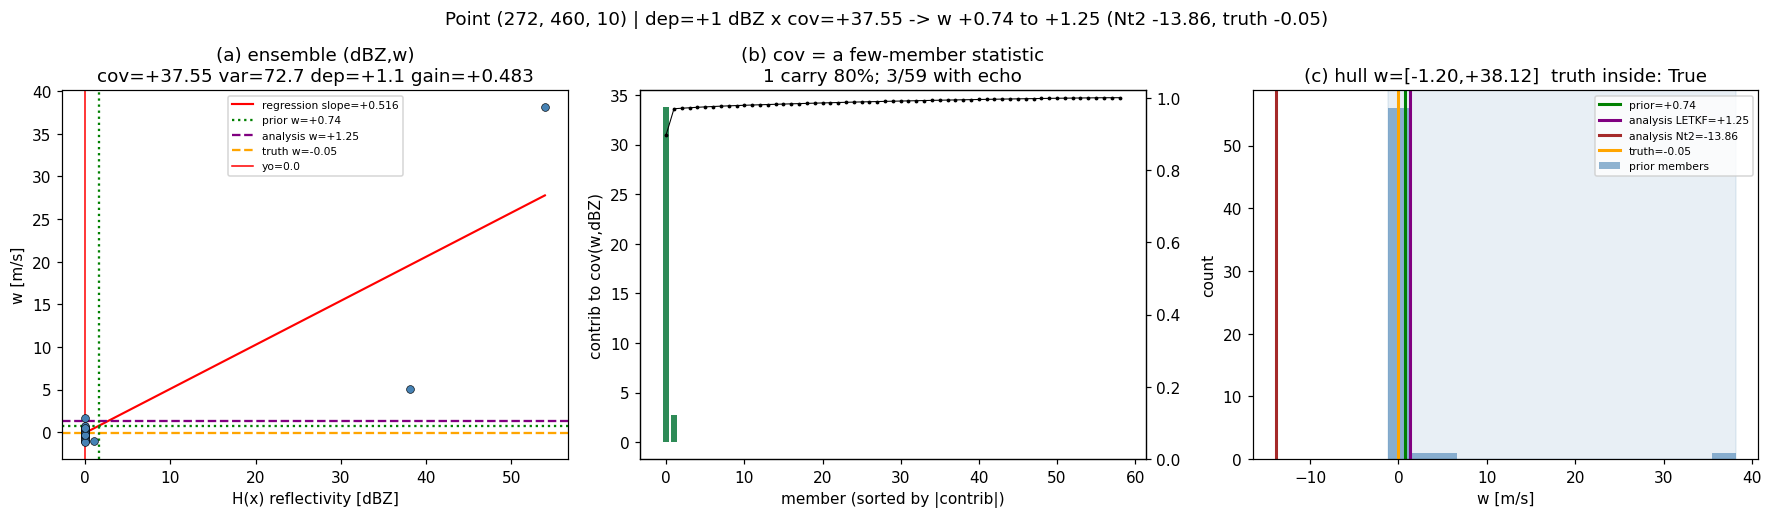

--- helpful: (254, 726, 10) ---


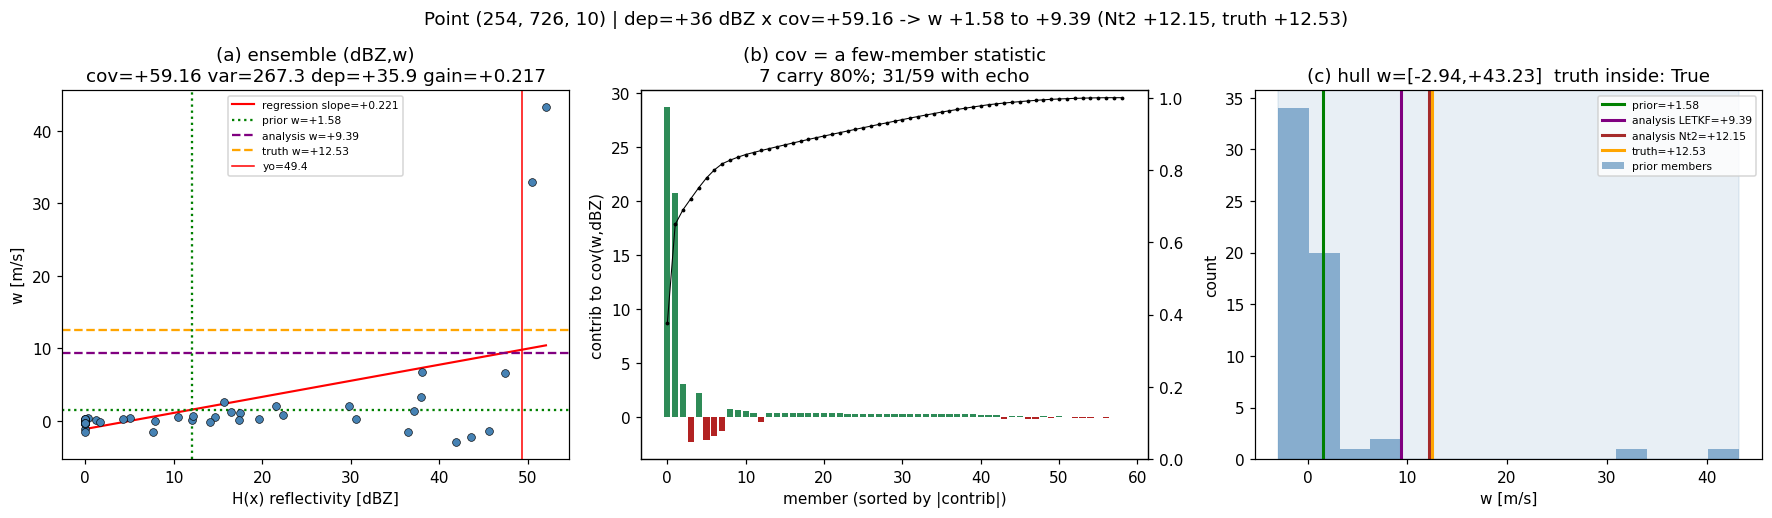

--- sign-flip: (58, 254, 8) ---


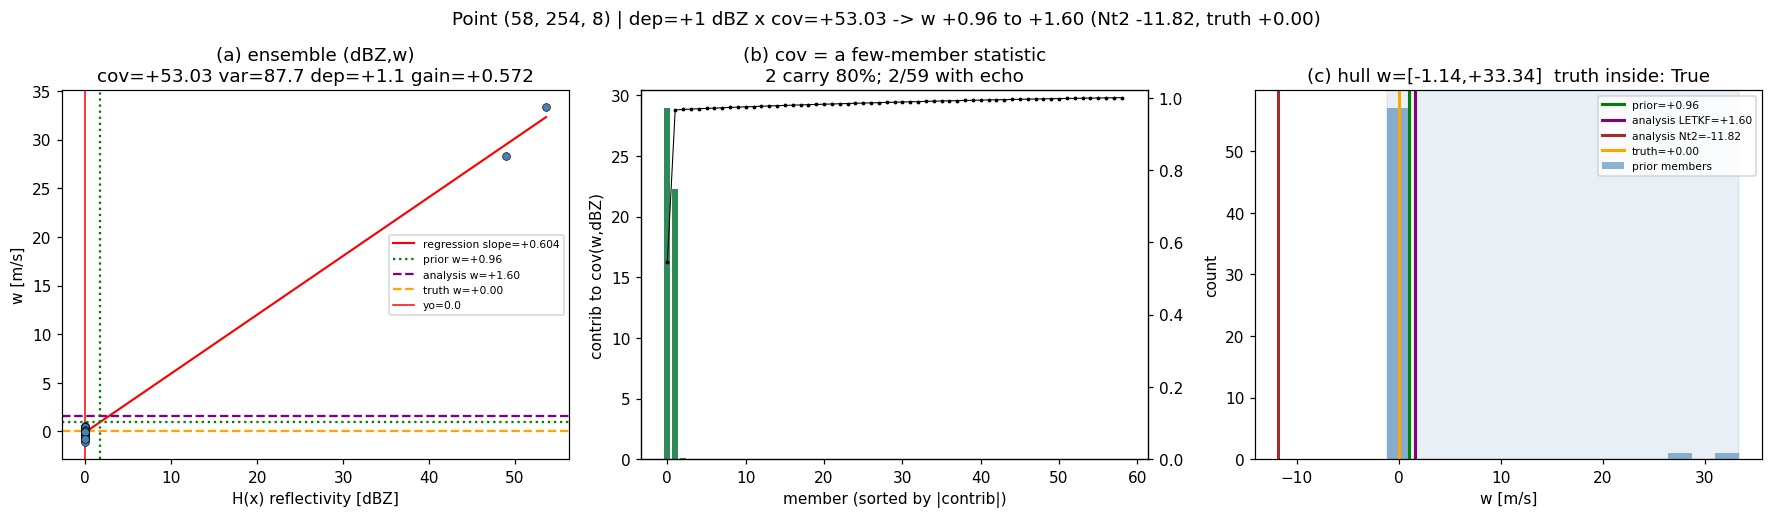

In [12]:
sel_lookup = {(int(I[s]), int(J[s]), int(K[s])): p for p, s in enumerate(sel)}

def deep_dive(cell):
    p = sel_lookup.get(tuple(int(x) for x in cell))
    if p is None:
        print('cell not in sel'); return
    s = sel[p]
    hm_, wm_ = h_e[p].mean(), w_e[p].mean()
    cov, var, dep = cov_dir[p], var_dir[p], dep_b[s]
    g = cov / (var + R0)
    wa_L, wa_T, wtc = wa['Nt1'][s], wa['Nt2'][s], wt[s]
    c_ = (w_e[p] - wm_) * (h_e[p] - hm_) / (NE - 1)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)
    ax[0].scatter(h_e[p], w_e[p], s=26, c='steelblue', edgecolors='k', linewidths=.4, zorder=3)
    hh = np.linspace(h_e[p].min(), max(h_e[p].max(), yo_cln[s]), 50)
    ax[0].plot(hh, wm_ + cov / var * (hh - hm_), 'r-', lw=1.4, label=f'regression slope={cov/var:+.3f}')
    ax[0].axhline(wm_, c='g', ls=':', label=f'prior w={wm_:+.2f}')
    ax[0].axhline(wa_L, c='purple', ls='--', label=f'analysis w={wa_L:+.2f}')
    ax[0].axhline(wtc, c='orange', ls='--', label=f'truth w={wtc:+.2f}')
    ax[0].axvline(hm_, c='g', ls=':'); ax[0].axvline(yo_cln[s], c='r', lw=1, label=f'yo={yo_cln[s]:.1f}')
    ax[0].set_xlabel('H(x) reflectivity [dBZ]'); ax[0].set_ylabel('w [m/s]')
    ax[0].set_title(f'(a) ensemble (dBZ,w)\ncov={cov:+.2f} var={var:.1f} dep={dep:+.1f} gain={g:+.3f}')
    ax[0].legend(fontsize=7)
    order = np.argsort(np.abs(c_))[::-1]
    csum = np.cumsum(np.abs(c_[order])) / np.abs(c_).sum()
    ax[1].bar(range(NE), c_[order], color=np.where(c_[order] < 0, 'firebrick', 'seagreen'))
    n80 = int(np.searchsorted(csum, 0.80)) + 1
    ax[1].set_title(f'(b) cov = a few-member statistic\n{n80} carry 80%; '
                    f'{int((h_e[p] > DBZ_MIN).sum())}/{NE} with echo')
    ax[1].set_xlabel('member (sorted by |contrib|)'); ax[1].set_ylabel('contrib to cov(w,dBZ)')
    axt = ax[1].twinx(); axt.plot(range(NE), csum, 'k.-', ms=3, lw=.7); axt.set_ylim(0, 1.02)
    ax[2].hist(w_e[p], bins=15, color='steelblue', alpha=.6, label='prior members')
    for x_, c2, l_ in ((wm_, 'g', 'prior'), (wa_L, 'purple', 'analysis LETKF'),
                       (wa_T, 'brown', 'analysis Nt2'), (wtc, 'orange', 'truth')):
        ax[2].axvline(x_, c=c2, lw=2, label=f'{l_}={x_:+.2f}')
    ax[2].axvspan(w_e[p].min(), w_e[p].max(), color='steelblue', alpha=.12)
    ax[2].set_xlabel('w [m/s]'); ax[2].set_ylabel('count')
    ti = w_e[p].min() <= wtc <= w_e[p].max()
    ax[2].set_title(f'(c) hull w=[{w_e[p].min():+.2f},{w_e[p].max():+.2f}]  truth inside: {ti}')
    ax[2].legend(fontsize=7)
    fig.suptitle(f'Point {tuple(int(x) for x in cell)} | dep={dep:+.0f} dBZ x cov={cov:+.2f} '
                 f'-> w {wm_:+.2f} to {wa_L:+.2f} (Nt2 {wa_T:+.2f}, truth {wtc:+.2f})')
    plt.show()

for lbl, cell in REP.items():
    print(f'--- {lbl}: {cell} ---')
    deep_dive(cell)

## 8. Vertical cross-section around the point: spatial extent of the condition

Shows how many members carry echo, the reflectivity and `w` (truth vs prior mean) and the `w`
spread, on a fixed-`j` cross-section.

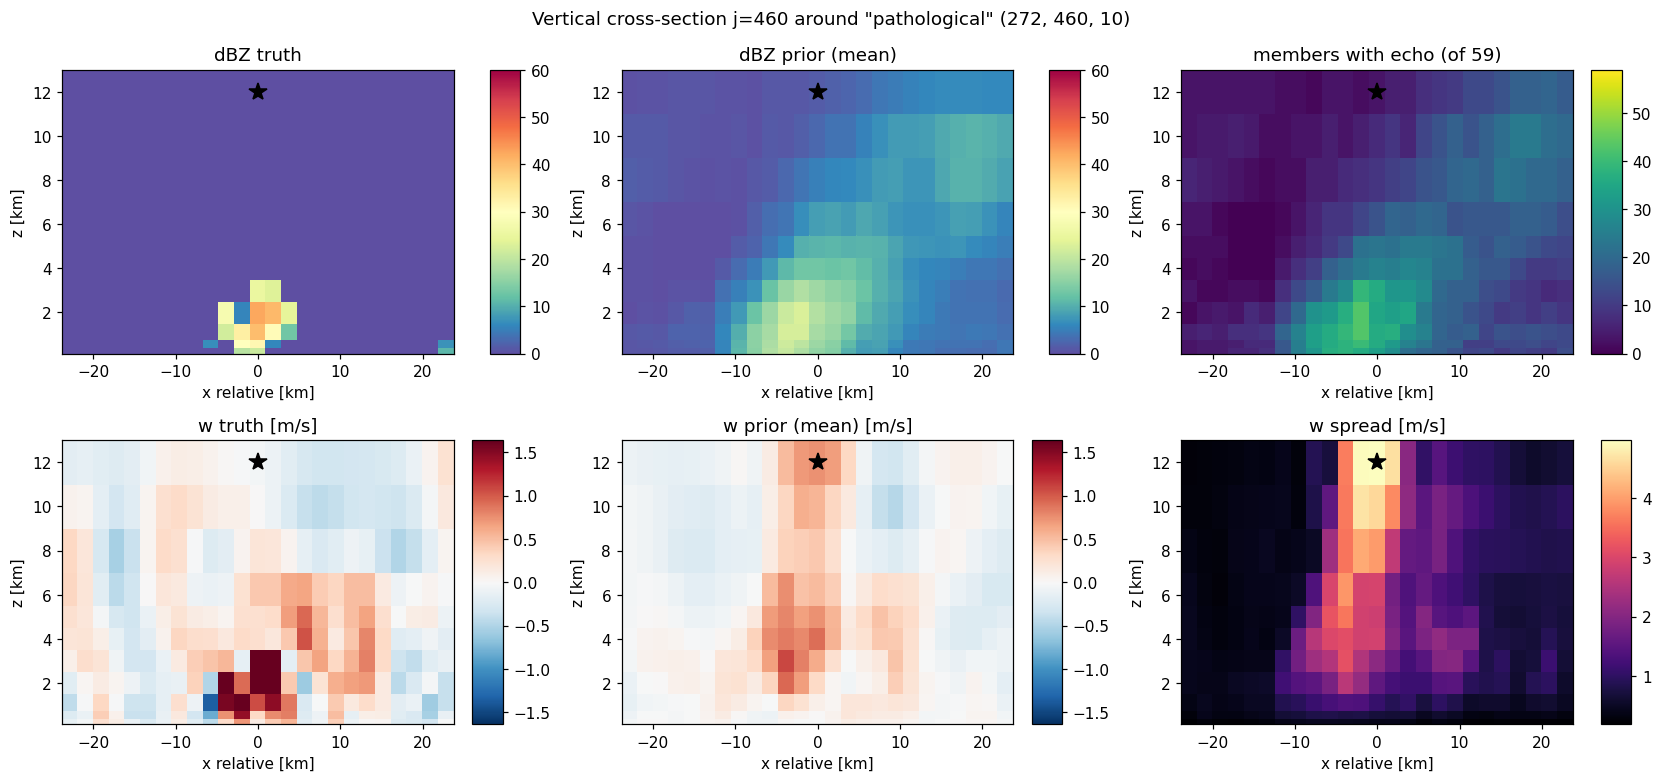

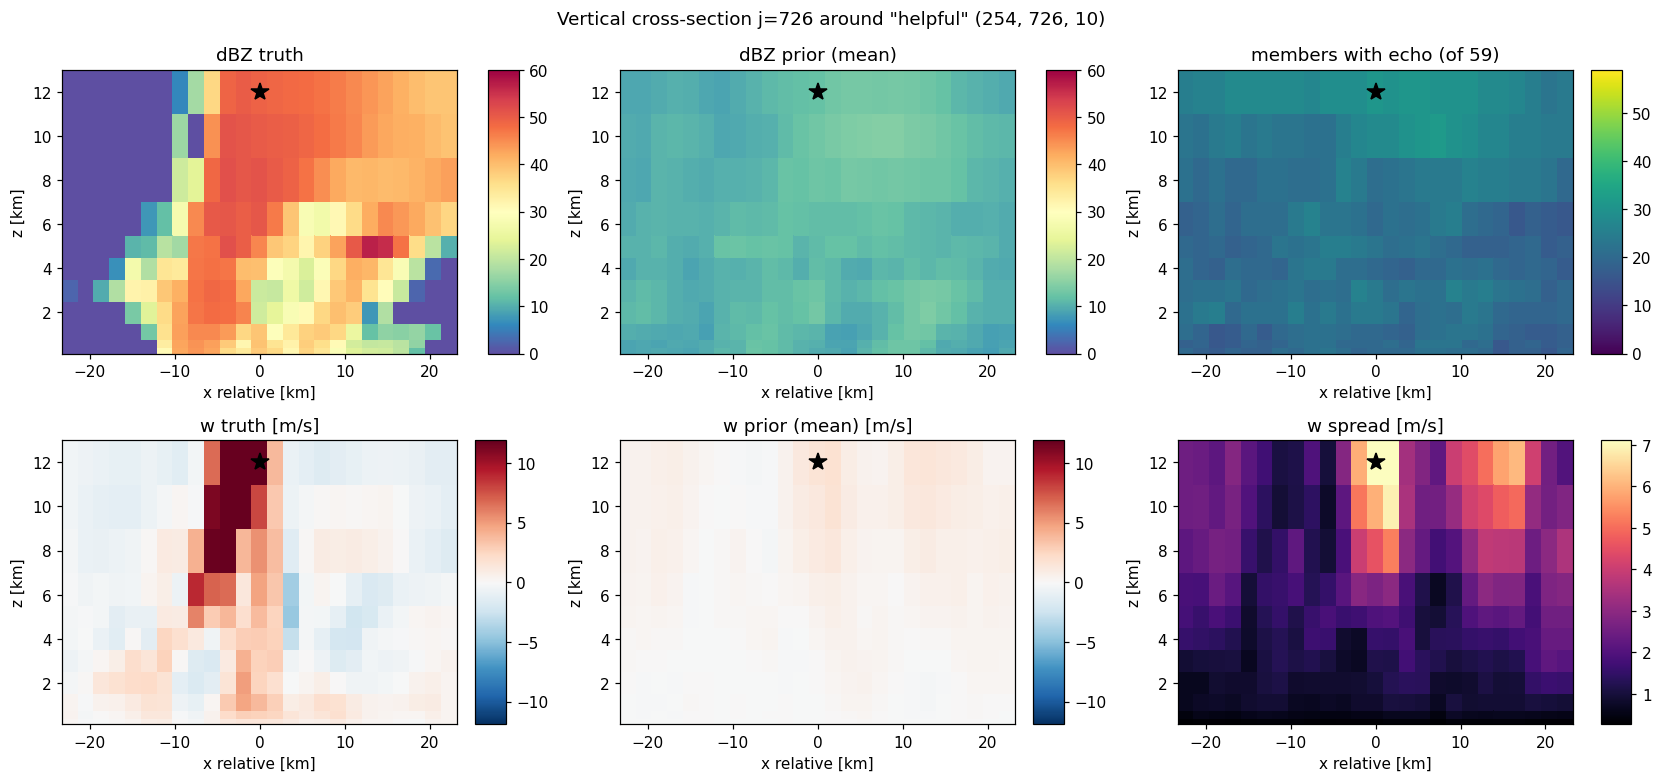

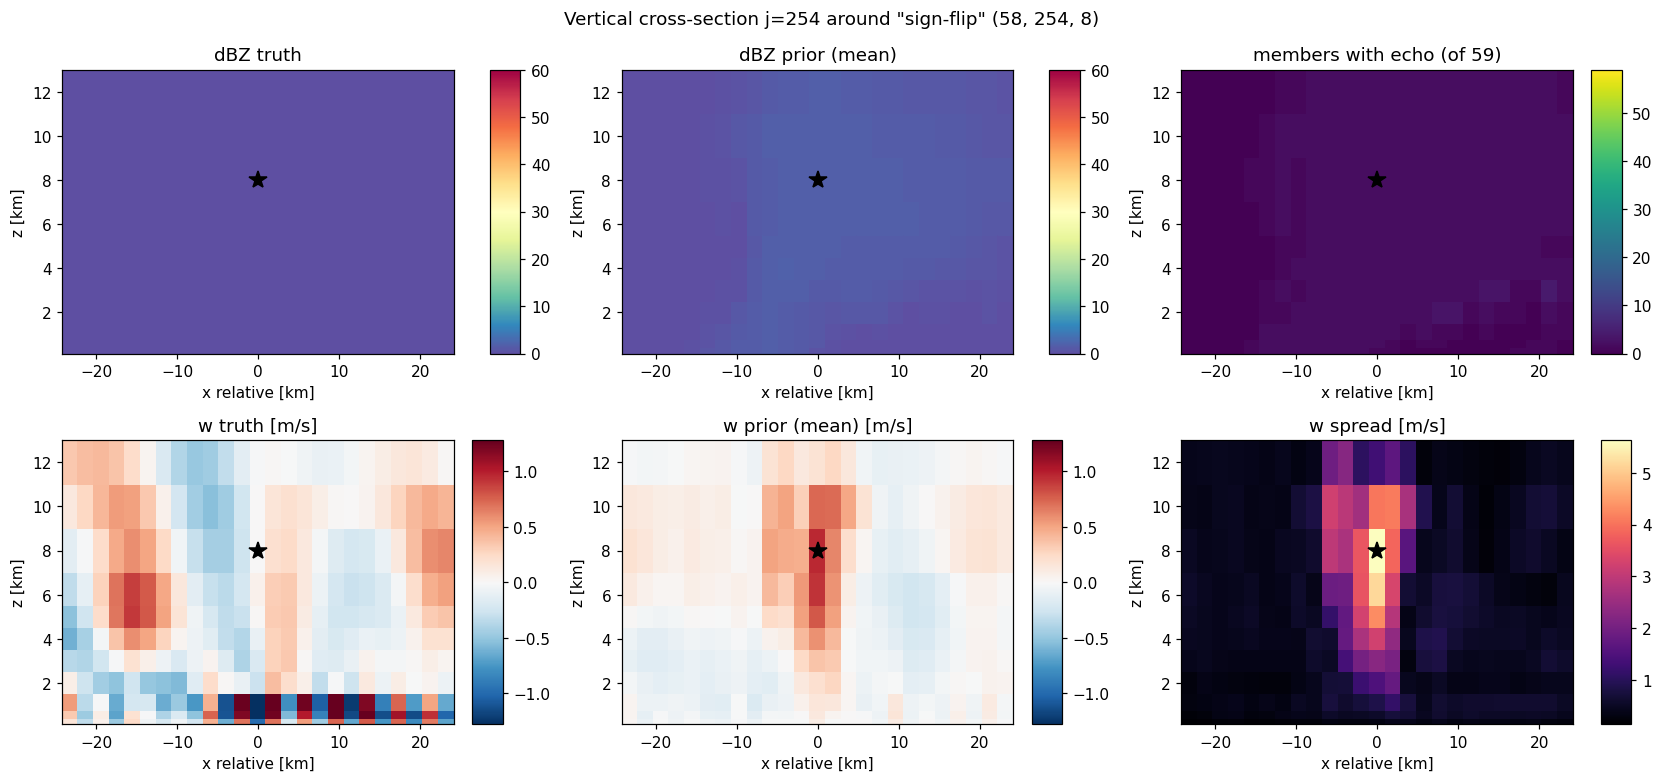

In [13]:
def cross_section(lbl):
    X = XS[lbl]; cube = X['cube']; i0, ci, cj, ck = X['i0'], X['ci'], X['cj'], X['ck']
    ni, nz = cube.shape[0], cube.shape[1]
    memb = [m for m in range(cube.shape[2]) if m != TM]
    prior = cube[:, :, memb, :]        # (ni,nz,NE,8)
    truth = cube[:, :, TM, :]          # (ni,nz,8)
    h_pri = Hmembers(prior)            # (ni,nz,NE)
    Xkm = X['x'] - X['x'][ci - i0, 0]  # x relative to the point [km], (ni,nz)
    Zkm = np.broadcast_to(X['zk'][None, :], (ni, nz))
    dbz_tru  = Hmembers(truth); dbz_pri = h_pri.mean(2)
    n_ech    = (h_pri > DBZ_MIN).sum(2)
    w_tru    = truth[..., IW]; w_pri = prior[..., IW].mean(2); w_sd = prior[..., IW].std(2)
    wlim = float(np.nanpercentile(np.abs(np.concatenate([w_pri.ravel(), w_tru.ravel()])), 99)) or 1.0
    fig, ax = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
    panels = [(dbz_tru, 'dBZ truth', dict(cmap='Spectral_r', vmin=0, vmax=60)),
              (dbz_pri, 'dBZ prior (mean)', dict(cmap='Spectral_r', vmin=0, vmax=60)),
              (n_ech,   f'members with echo (of {NE})', dict(cmap='viridis', vmin=0, vmax=NE)),
              (w_tru,   'w truth [m/s]', dict(cmap='RdBu_r', vmin=-wlim, vmax=wlim)),
              (w_pri,   'w prior (mean) [m/s]', dict(cmap='RdBu_r', vmin=-wlim, vmax=wlim)),
              (w_sd,    'w spread [m/s]', dict(cmap='magma'))]
    for a, (C, ttl, kw) in zip(ax.ravel(), panels):
        p = a.pcolormesh(Xkm, Zkm, C, shading='nearest', **kw)
        fig.colorbar(p, ax=a, fraction=.046)
        a.plot(0, X['zk'][ck], 'k*', ms=12)
        a.set_title(ttl); a.set_xlabel('x relative [km]'); a.set_ylabel('z [km]')
    fig.suptitle(f'Vertical cross-section j={cj} around "{lbl}" {(ci,cj,ck)}')
    plt.show()

for lbl in XS:
    cross_section(lbl)

## 9. Summary and export

In [14]:
np.savez_compressed(
    OUT,
    i=I, j=J, k=K,
    x_km=col('x_km', m_l, o_l), y_km=col('y_km', m_l, o_l), z_km=col('z_km', m_l, o_l),
    dep_b=dep_b, hxf=hxf, yo_clean=yo_cln, var_h=var_h, skew_w=skew_w, spread_w=sprd_w,
    wf=wf, wt=wt, wa_Nt1=wa['Nt1'], wa_Nt2=wa['Nt2'], wa_Nt3=wa['Nt3'], wa_AOEI=wa['AOEI'],
    Ef=Ef, Ea_Nt1=Ea['Nt1'], Ea_Nt2=Ea['Nt2'], Ea_Nt3=Ea['Nt3'], Ea_AOEI=Ea['AOEI'],
    cov_wh=cov_wh, gain=gain, n_active=NACT, frac_echo=FRAC, cov_dir=COVD,
    wa_outside_hull=WOUT, truth_outside_hull=TOUT,
    pathological_dbz=pathological, temper_helpful_dbz=temper_helpful,
    w_patho=w_patho, w_helpful=w_helpful, w_worse_Nt2=w_worse['Nt2'], sflip_Nt2=sflip['Nt2'],
    valid=valid,
)
ctrl_m = (~flag) & valid
print('saved to', OUT)
print(f'\nSummary (Ne=59, loc=0.1, {int(valid.sum()):,} valid points):')
print(f'  pathological-dBZ (Nt2 worse than standard and prior): {int(pathological.sum()):,}')
print(f'  pathological-w   (Nt2 worse than standard and prior): {int(w_patho.sum()):,}')
print(f'  helpful-w        (Nt2 better than both)             : {int(w_helpful.sum()):,}')
print(f'  w worsens (Nt2) / sign change (Nt2)                  : {int(w_worse["Nt2"].sum()):,} / {int(sflip["Nt2"].sum()):,}')
print(f'\n  median n_active  patho-w vs control: {np.nanmedian(NACT[w_patho]):.1f} vs {np.nanmedian(NACT[ctrl_m]):.1f}')
print(f'  median |skew w|  patho-w vs control: {np.nanmedian(np.abs(skew_w[w_patho])):.2f} vs {np.nanmedian(np.abs(skew_w[ctrl_m])):.2f}')
print(f'  median |gain|    patho-w vs control: {np.nanmedian(np.abs(gain[w_patho])):.3f} vs {np.nanmedian(np.abs(gain[ctrl_m])):.3f}')

# verification asserts (fail loud)
assert int(w_worse['Nt2'].sum()) > 0, 'no points where w worsens -- check'
assert int(w_patho.sum()) > 0 or int(pathological.sum()) > 0, 'no pathological category populated'
print('\nVERIFICATION OK')

saved to /nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived_S10_flagged_points.npz

Summary (Ne=59, loc=0.1, 750,908 valid points):
  pathological-dBZ (Nt2 worse than standard and prior): 98,055
  pathological-w   (Nt2 worse than standard and prior): 301,453
  helpful-w        (Nt2 better than both)             : 263,589
  w worsens (Nt2) / sign change (Nt2)                  : 383,142 / 65,078

  median n_active  patho-w vs control: 5.0 vs 2.0
  median |skew w|  patho-w vs control: 0.94 vs 0.50
  median |gain|    patho-w vs control: 0.010 vs 0.003

VERIFICATION OK
